## Connect to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Install Libraries

In [ ]:
!pip install numpy==1.26.4 ultralytics mediapipe==0.10.11
# opencv-python scikit-learn matplotlib xgboost mediapipe


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

## Importing Libraries

In [ ]:
# Import necessary libraries for the project

import matplotlib.pyplot as plt  # For plotting and visualization
import cv2  # OpenCV for image and video processing
import os  # For interacting with the operating system (file paths, directories)
import numpy as np  # For numerical operations and array handling
from ultralytics import YOLO  # For YOLO pose estimation model
import mediapipe as mp  # For MediaPipe pose estimation models
from sklearn.model_selection import train_test_split  # For splitting data into train/test sets
from sklearn.preprocessing import MinMaxScaler, LabelEncoder  # For feature scaling and label encoding
from sklearn.linear_model import LogisticRegression  # Logistic Regression classifier
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from xgboost import XGBClassifier  # XGBoost classifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix  # Evaluation metrics
import seaborn as sns  # For advanced data visualization (heatmaps, etc.)
import pandas as pd  # For data manipulation and analysis
import joblib  # For saving and loading models and preprocessing objects
from collections import Counter  # For counting occurrences of elements (e.g., predictions)
import shutil  # For high-level file operations (copying, removing directories)
from IPython.display import display, Image  # Import display and Image from IPython.display for displaying images in the notebook.


## Setup the path of your Data Dir which has the following dir in is



1.   Gym
2.   Dancing
3.   Cooking



In [ ]:
# Data Dir where all the classes folders exists
DATA_DIR = '/content/drive/MyDrive/Data'

# Change this to the Class name in Data Dir
valid_classes = ['Cooking', 'Dancing', 'Gym']

# Video Prediction Path
video_path = '/content/drive/MyDrive/Data/Dancing/2-#jennielikejennie #jennie #likejennie #dancecove7493853985120505094.mp4'


## Configurations

In [ ]:
# Directory structure
FRAME_DIR = os.path.join(DATA_DIR, 'Frames')  # Directory to store extracted frames from videos
POSE_DIR = os.path.join(DATA_DIR, 'Poses')    # Directory to store extracted pose keypoints
PREDICTION_DIR = os.path.join(DATA_DIR, 'Predictions')  # Directory to store prediction outputs (e.g., annotated videos)
MODEL_DIR = os.path.join(DATA_DIR, 'Models')  # Directory to store trained ML models and related files

# Pose estimation models
POSE_MODELS = {
    'yolov': {'path': 'yolov8n-pose.pt', 'keypoints': 17},  # YOLOv8 pose model with 17 keypoints and model path
    'mediapipe': {'keypoints': 33},                         # MediaPipe pose model with 33 keypoints (no path needed)
    'blazepose': {'keypoints': 33}                          # BlazePose model with 33 keypoints (no path needed)
}

# COCO-compatible keypoint indices (subset from 33 to 17 for consistency)
# These indices map the 33-keypoint format (used by MediaPipe/BlazePose) to the 17-keypoint COCO format
# COCO-compatible keypoint indices (subset from 33 to 17 for consistency)
COCO_KEYPOINTS = [
    0,  # Nose
    2,  # Left eye
    5,  # Right eye
    7,  # Left ear
    8,  # Right ear
    11,  # Left shoulder
    12,  # Right shoulder
    13,  # Left elbow
    14,  # Right elbow
    15,  # Left wrist
    16,  # Right wrist
    23,  # Left hip
    24,  # Right hip
    25,  # Left knee
    26,  # Right knee
    27,  # Left ankle
    28   # Right ankle
]

# COCO skeleton for visualization
COCO_SKELETON = [
    (0, 1), (0, 2), (1, 3), (2, 4),  # Head
    (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),  # Arms
    (5, 11), (6, 12), (11, 12),  # Torso
    (11, 13), (12, 14), (13, 15), (14, 16)  # Legs
]


## Extarct Frames from Videos

In [ ]:
def extract_frames_from_videos(data_dir, output_dir, frame_rate=1, max_videos=None):
    """
    Extract frames from videos, organized by class labels.
    """
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)
    # Iterate over each class label directory in the data directory
    for label in os.listdir(data_dir):
        label_path = os.path.join(data_dir, label)
        # Skip if not a directory (e.g., skip files)
        if not os.path.isdir(label_path):
            continue
        # Create a corresponding output directory for this label
        label_output_dir = os.path.join(output_dir, label)
        os.makedirs(label_output_dir, exist_ok=True)
        # List all video files with supported extensions in the label directory
        video_files = [f for f in os.listdir(label_path) if f.lower().endswith(('.mp4', '.avi', '.mov'))]
        # Loop through each video file, up to max_videos if specified
        for i, video_file in enumerate(video_files):
            if max_videos is not None and i >= max_videos:
                break
            video_path = os.path.join(label_path, video_file)
            cap = cv2.VideoCapture(video_path)
            # Check if the video file can be opened
            if not cap.isOpened():
                print(f"Failed to open video: {video_path}")
                continue
            fps = cap.get(cv2.CAP_PROP_FPS)
            # Skip videos with invalid FPS
            if fps <= 0:
                print(f"Invalid FPS for {video_file}, skipping")
                cap.release()
                continue
            count = 0  # Frame counter
            saved = 0  # Saved frame counter
            # Read frames from the video
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                # Save frame at the specified frame rate interval
                if int(count % (fps // frame_rate)) == 0:
                    save_path = os.path.join(label_output_dir, f"{os.path.splitext(video_file)[0]}_{saved}.jpg")
                    cv2.imwrite(save_path, frame)
                    saved += 1
                count += 1
            cap.release()
            print(f"Extracted {saved} frames from {video_file}")

    # Remove any redundant 'Frames' directory inside the output directory
    redundant_dir = os.path.join(output_dir, 'Frames')
    if os.path.exists(redundant_dir):
        shutil.rmtree(redundant_dir)
    # Remove any redundant 'Poses' directory inside the output directory
    poses_dir = os.path.join(output_dir, 'Poses')
    if os.path.exists(poses_dir):
        shutil.rmtree(poses_dir)


## Extarct Poses from Frames and Strore the Poses in a seperate POSE Dir

In [ ]:
def extract_and_save_poses(
    frames_dir,
    poses_dir='Data/Poses',
    pose_model='yolov',
    model_path=None,
    max_visualizations_per_class=3,
    visualize=True,
    valid_classes=valid_classes
):
    """
    Extract and save keypoints using specified pose estimation model.
    """
    # Ensure the output directory for poses exists
    os.makedirs(poses_dir, exist_ok=True)
    # Create a subdirectory for the selected pose model
    model_pose_dir = os.path.join(poses_dir, pose_model)
    # Dictionary to store keypoints for all classes
    all_class_keypoints = {}

    try:
        # Initialize the pose estimation model based on the selected type
        if pose_model == 'yolov':
            model = YOLO(model_path)
        elif pose_model == 'mediapipe':
            mp_pose = mp.solutions.pose
            model = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)
        elif pose_model == 'blazepose':
            mp_holistic = mp.solutions.holistic
            model = mp_holistic.Holistic(static_image_mode=True, min_detection_confidence=0.5)
        else:
            # Raise error if unsupported model is specified
            raise ValueError(f"Unsupported pose model: {pose_model}")
    except Exception as e:
        # Log and return if model loading fails
        print(f"Failed to load {pose_model} model: {e}")
        return all_class_keypoints

    # Iterate over each class directory in the frames directory
    for label in os.listdir(frames_dir):
        if label not in valid_classes:
            # Skip directories that are not valid classes
            print(f"Skipping invalid directory: {label}")
            continue
        label_dir = os.path.join(frames_dir, label)
        if not os.path.isdir(label_dir):
            continue
        # Create output directory for the current class and pose model
        label_pose_dir = os.path.join(model_pose_dir, label)
        os.makedirs(label_pose_dir, exist_ok=True)
        print(f"Processing class: {label} with {pose_model}")
        # List all jpg images in the class directory
        images = [f for f in os.listdir(label_dir) if f.endswith('.jpg')]
        # List to store keypoints for this class
        class_keypoints = []
        # Counter for visualizations per class
        vis_count = 0

        # Process each image in the class directory
        for img_file in images:
            img_path = os.path.join(label_dir, img_file)
            img = cv2.imread(img_path)
            if img is None:
                # Log error if image cannot be loaded
                print(f"Failed to load image: {img_path}")
                continue
            # Convert image to RGB for model processing
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            print(f"Processing {img_file}: shape={img_rgb.shape}, dtype={img_rgb.dtype}")
            keypoints = None
            try:
                # Run pose estimation based on the selected model
                if pose_model == 'yolov':
                    results = model(img_path)
                    # Check for valid keypoints and single detection
                    if results[0].keypoints is None or len(results[0].keypoints) != 1:
                        print(f"Skipping {img_file}: No valid keypoints or multiple detections")
                        continue
                    # Extract keypoints as numpy array
                    keypoints = results[0].keypoints.xy.cpu().numpy()[0]
                elif pose_model == 'mediapipe':
                    results = model.process(img_rgb)
                    if not results.pose_landmarks:
                        print(f"Skipping {img_file}: No pose detected")
                        continue
                    # Extract and scale keypoints to image size
                    keypoints = np.array([[lm.x * img.shape[1], lm.y * img.shape[0]]
                                         for lm in results.pose_landmarks.landmark])
                    # Subset to 17 COCO keypoints
                    keypoints = keypoints[COCO_KEYPOINTS]
                elif pose_model == 'blazepose':
                    results = model.process(img_rgb)
                    if not results.pose_landmarks:
                        print(f"Skipping {img_file}: No pose detected")
                        continue
                    # Extract and scale keypoints to image size
                    keypoints = np.array([[lm.x * img.shape[1], lm.y * img.shape[0]]
                                         for lm in results.pose_landmarks.landmark])
                    # Subset to 17 COCO keypoints
                    keypoints = keypoints[COCO_KEYPOINTS]

                # If valid keypoints are found, save and optionally visualize
                if keypoints is not None and np.any(keypoints):
                    # Save keypoints as .npy file
                    pose_save_path = os.path.join(label_pose_dir, f"{os.path.splitext(img_file)[0]}.npy")
                    np.save(pose_save_path, keypoints)
                    class_keypoints.append(keypoints)

                    # Visualize keypoints and skeleton if enabled and limit not reached
                    if visualize and vis_count < max_visualizations_per_class:
                        img_vis = img_rgb.copy()
                        # Draw keypoints as circles
                        for x, y in keypoints:
                            if x > 0 and y > 0:
                                cv2.circle(img_vis, (int(x), int(y)), 4, (0, 255, 0), -1)
                        # Draw skeleton connections
                        for idx1, idx2 in COCO_SKELETON:
                            if idx1 < len(keypoints) and idx2 < len(keypoints):
                                pt1 = keypoints[idx1]
                                pt2 = keypoints[idx2]
                                if pt1[0] > 0 and pt1[1] > 0 and pt2[0] > 0 and pt2[1] > 0:
                                    cv2.line(img_vis, (int(pt1[0]), int(pt1[1])),
                                            (int(pt2[0]), int(pt2[1])), (255, 0, 0), 2)
                        # Display the visualization
                        plt.figure(figsize=(6, 6))
                        plt.imshow(img_vis)
                        plt.title(f"{label}: {img_file} ({pose_model})")
                        plt.axis('off')
                        plt.show()
                        vis_count += 1
                else:
                    # Log warning if keypoints are invalid
                    print(f"Skipping {img_file}: Invalid keypoints")

            except Exception as e:
                # Log any errors during processing
                print(f"Error processing {img_file} with {pose_model}: {e}")
                continue

        # Save all keypoints for this class if any were found
        if class_keypoints:
            all_class_keypoints[label] = np.array(class_keypoints)
            print(f"Saved {len(class_keypoints)} valid poses for class {label}")
        else:
            print(f"No valid poses found for class {label}")

    # Release resources for mediapipe/blazepose models
    if pose_model in ['mediapipe', 'blazepose']:
        model.close()

    # Return dictionary of all class keypoints
    return all_class_keypoints


## Train and Evaluate Models

In [ ]:
def train_and_evaluate_models(poses_dir, model_save_path, le_save_path, scaler_save_path):
    """
    Train and evaluate four ML models on pose keypoints.
    """
    X, y = [], []
    # Iterate through each label (class) directory in the poses directory
    for label in os.listdir(poses_dir):
        label_pose_dir = os.path.join(poses_dir, label)
        if not os.path.isdir(label_pose_dir):
            continue  # Skip if not a directory
        # Iterate through each .npy file (keypoints) in the label directory
        for npy_file in os.listdir(label_pose_dir):
            if npy_file.endswith('.npy'):
                keypoints = np.load(os.path.join(label_pose_dir, npy_file))
                X.append(keypoints.flatten())  # Flatten keypoints and add to feature list
                y.append(label)  # Add corresponding label

    if not X:
        raise ValueError(f"No keypoints found in {poses_dir}")  # Raise error if no data found

    X = np.array(X)  # Convert feature list to numpy array
    y = np.array(y)  # Convert label list to numpy array

    # Encode string labels into integers
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    joblib.dump(le, le_save_path)  # Save the label encoder for future use

    # Scale features to [0, 1] range
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    joblib.dump(scaler, scaler_save_path)  # Save the scaler for future use

    # Split data into training and testing sets (stratified by label)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    # Define four machine learning models to train and evaluate
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'SVM': SVC(kernel='rbf', random_state=42, probability=True),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    }

    results = {}  # Dictionary to store evaluation results for each model
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)  # Train the model
        y_pred = model.predict(X_test)  # Predict on test set

        # Calculate evaluation metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        cm = confusion_matrix(y_test, y_pred)

        # Store metrics and confusion matrix in results dictionary
        results[name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'confusion_matrix': cm
        }

        # Log evaluation metrics
        print(f"Evaluation metrics for {name}:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print("Confusion Matrix:")
        print(cm)

        # Save the Random Forest model to disk
        if name == 'Random Forest':
            joblib.dump(model, model_save_path)

    # Get the name of the pose model (parent directory of poses_dir)
    pose_model = os.path.basename(os.path.dirname(poses_dir))
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    model_names = list(models.keys())
    # Collect metric values for each model for plotting
    metric_values = {
        'Accuracy': [results[model]['accuracy'] for model in model_names],
        'Precision': [results[model]['precision'] for model in model_names],
        'Recall': [results[model]['recall'] for model in model_names],
        'F1-Score': [results[model]['f1'] for model in model_names]
    }

    # Plot bar chart comparing metrics across models
    plt.figure(figsize=(12, 6))
    x = np.arange(len(model_names))
    width = 0.2
    for i, metric in enumerate(metrics):
        plt.bar(x + i * width, metric_values[metric], width, label=metric)

    plt.xlabel('Models')
    plt.ylabel('Scores')
    plt.title(f'Model Performance Comparison ({pose_model})')
    plt.xticks(x + width * 1.5, model_names)
    plt.legend()
    plt.ylim(0, 1)
    # Annotate bars with metric values
    for i, metric in enumerate(metrics):
        for j, value in enumerate(metric_values[metric]):
            plt.text(j + i * width, value + 0.01, f"{value:.4f}", ha='center', va='bottom')

    plt.tight_layout()
    # Save the metrics comparison plot
    plt.savefig(os.path.join(os.path.dirname(model_save_path), f'model_metrics_comparison_{pose_model}.png'))
    plt.close()

    # Plot confusion matrices for each model
    plt.figure(figsize=(12, 10))
    for i, (name, result) in enumerate(results.items(), 1):
        plt.subplot(2, 2, i)
        sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                    xticklabels=le.classes_, yticklabels=le.classes_)
        plt.title(f'Confusion Matrix: {name} ({pose_model})')
        plt.xlabel('Predicted')
        plt.ylabel('True')
    plt.tight_layout()
    # Save the confusion matrices plot
    plt.savefig(os.path.join(os.path.dirname(model_save_path), f'confusion_matrices_{pose_model}.png'))
    plt.close()

    # Save performance metrics to a CSV file
    results_df = pd.DataFrame({
        'Model': model_names,
        'Accuracy': [results[model]['accuracy'] for model in model_names],
        'Precision': [results[model]['precision'] for model in model_names],
        'Recall': [results[model]['recall'] for model in model_names],
        'F1-Score': [results[model]['f1'] for model in model_names]
    })
    results_df.to_csv(os.path.join(os.path.dirname(model_save_path), f'model_performance_{pose_model}.csv'), index=False)

    return results, results_df  # Return results dictionary and DataFrame


## Inference of Trained Model on Video

In [ ]:
def predict_and_visualize_video(
    video_path,
    output_path,
    pose_model='yolov',
    model_path=None,
    clf_model_path=None,
    le_path=None,
    scaler_path=None
):
    """
    Process a test video with specified pose estimation model, predict classes, and visualize skeletons.
    """
    # Ensure output directory exists
    output_dir = os.path.dirname(output_path)
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    # Load the pose estimation model based on the selected type
    try:
        if pose_model == 'yolov':
            model = YOLO(model_path)  # Load YOLOv pose model
        elif pose_model == 'mediapipe':
            mp_pose = mp.solutions.pose
            model = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5)  # Load MediaPipe pose model
        elif pose_model == 'blazepose':
            mp_holistic = mp.solutions.holistic
            model = mp_holistic.Holistic(static_image_mode=False, min_detection_confidence=0.5)  # Load BlazePose model
        else:
            raise ValueError(f"Unsupported pose model: {pose_model}")
    except Exception as e:
        print(f"Failed to load pose model {pose_model}: {e}")
        return None, {}

    # Load classifier, label encoder, and scaler
    try:
        clf_model = joblib.load(clf_model_path)
        le = joblib.load(le_path)
        scaler = joblib.load(scaler_path)
    except Exception as e:
        print(f"Failed to load model or scaler: {e}")
        return None, {}

    # Open the input video file
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Could not open video: {video_path}")
        return None, {}

    # Get video properties (width, height, fps)
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    if fps <= 0:
        fps = 30  # Default FPS if not available

    # Initialize video writer for output video
    try:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))
        if not out.isOpened():
            raise ValueError("Failed to initialize video writer with mp4v codec")
    except:
        # Fallback to XVID codec if mp4v fails
        print(f"mp4v codec failed for {output_path}, trying XVID")
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        output_path = os.path.splitext(output_path)[0] + '.avi'
        out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))
        if not out.isOpened():
            print(f"Failed to initialize video writer with XVID codec")
            return None, {}

    predictions = []  # Store predictions for each frame

    # Process each frame in the video
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break  # End of video

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert frame to RGB

        keypoints = None  # Initialize keypoints variable
        try:
            # Extract keypoints using the selected pose model
            if pose_model == 'yolov':
                results = model(frame_rgb)
                if results[0].keypoints is not None and len(results[0].keypoints) == 1:
                    keypoints = results[0].keypoints.xy.cpu().numpy()[0]
            elif pose_model == 'mediapipe':
                results = model.process(frame_rgb)
                if results.pose_landmarks:
                    keypoints = np.array([[lm.x * frame.shape[1], lm.y * frame.shape[0]]
                                         for lm in results.pose_landmarks.landmark])
                    keypoints = keypoints[COCO_KEYPOINTS]
            elif pose_model == 'blazepose':
                results = model.process(frame_rgb)
                if results.pose_landmarks:
                    keypoints = np.array([[lm.x * frame.shape[1], lm.y * frame.shape[0]]
                                         for lm in results.pose_landmarks.landmark])
                    keypoints = keypoints[COCO_KEYPOINTS]
        except Exception as e:
            print(f"Error processing video frame with {pose_model}: {e}")
            continue  # Skip frame on error

        # If keypoints are detected, predict class and visualize
        if keypoints is not None and np.any(keypoints):
            keypoints_flat = keypoints.flatten().reshape(1, -1)  # Flatten keypoints for classifier
            keypoints_scaled = scaler.transform(keypoints_flat)  # Scale keypoints
            pred = clf_model.predict(keypoints_scaled)  # Predict class
            pred_proba = clf_model.predict_proba(keypoints_scaled)[0]  # Get class probabilities
            pred_conf = np.max(pred_proba)  # Confidence of prediction
            pred_label = le.inverse_transform(pred)[0]  # Get class label
            predictions.append(pred_label)  # Store prediction

            # Draw keypoints on frame
            for x, y in keypoints:
                if x > 0 and y > 0:
                    cv2.circle(frame, (int(x), int(y)), 4, (0, 255, 0), -1)
            # Draw skeleton connections
            for idx1, idx2 in COCO_SKELETON:
                if idx1 < len(keypoints) and idx2 < len(keypoints):
                    pt1 = keypoints[idx1]
                    pt2 = keypoints[idx2]
                    if pt1[0] > 0 and pt1[1] > 0 and pt2[0] > 0 and pt2[1] > 0:
                        cv2.line(frame, (int(pt1[0]), int(pt1[1])),
                                (int(pt2[0]), int(pt2[1])), (255, 0, 0), 2)
            # Put predicted class label and confidence on frame
            cv2.putText(frame, f"Class: {pred_label} ({pred_conf:.2f})", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
        else:
            # If no pose detected, indicate on frame
            cv2.putText(frame, "No Pose Detected", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        out.write(frame)  # Write processed frame to output video

    cap.release()  # Release video capture
    out.release()  # Release video writer
    cv2.destroyAllWindows()  # Close any OpenCV windows

    # Close pose model if required (for MediaPipe/BlazePose)
    if pose_model in ['mediapipe', 'blazepose']:
        model.close()

    # Summarize predictions and log results
    if predictions:
        class_counts = Counter(predictions)  # Count occurrences of each class
        final_prediction = max(class_counts, key=class_counts.get)  # Most frequent class
        total_frames_with_pose = len(predictions)
        print(f"Video Prediction Summary ({pose_model}):")
        print(f"Total frames with valid poses: {total_frames_with_pose}")
        print(f"Final Prediction: {final_prediction}")
        print(f"Class Counts:")
        for cls, count in class_counts.items():
            print(f"  {cls}: {count} frames ({count/total_frames_with_pose*100:.2f}%)")
    else:
        print(f"Video Prediction Summary ({pose_model}):")
        print("No valid poses detected in the video.")
        final_prediction = None
        class_counts = {}

    print(f"Output video saved to: {output_path}")
    return final_prediction, class_counts  # Return final prediction and class counts


## Calling Function to Extracting Frames

In [ ]:
 # Extract frames
extract_frames_from_videos(DATA_DIR, FRAME_DIR, frame_rate=1, max_videos=5)


Extracted 17 frames from 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234.mp4
Extracted 6 frames from 1-perfect body shape ☺️🥰#asian #10k #cute #fyp #bo7453162246085053718.mp4
Extracted 16 frames from 1-WE ALL HAVE PERFECT BODIES. #GossipGirlHere #bod6982686642947493126.mp4
Extracted 18 frames from 1-omg body #jeonjongseo is perfect#fyp #kdrama #ba7376276334361742597.mp4
Extracted 9 frames from 2-All bodies are beautiful 💗 @amy_.miller 7138824443672939782.mp4
Extracted 62 frames from 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425.mp4
Extracted 38 frames from 2-#duet with @Donut Daddy #bread ＂Watch this sexy 7457996893155544352.mp4
Extracted 24 frames from 2-beef arayes 😮‍💨 My first time making these - wha7484026356867616055.mp4
Extracted 29 frames from 1-hope you are doing well ：) chinese pork daikon s7492837249147587846.mp4
Extracted 37 frames from 1-Episode 25 ｜ Teaching your next date how to cook7305106670345063713.mp4
Extracted 15 frames 

In [ ]:
all_results = {}


## Yolov Pose Estimation


=== Processing yolov ===


100%|██████████| 6.52M/6.52M [00:00<00:00, 70.2MB/s]


Processing class: Gym with yolov
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_0.jpg: shape=(1920, 1080, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Gym/1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_0.jpg: 640x384 1 person, 106.4ms
Speed: 20.0ms preprocess, 106.4ms inference, 558.1ms postprocess per image at shape (1, 3, 640, 384)


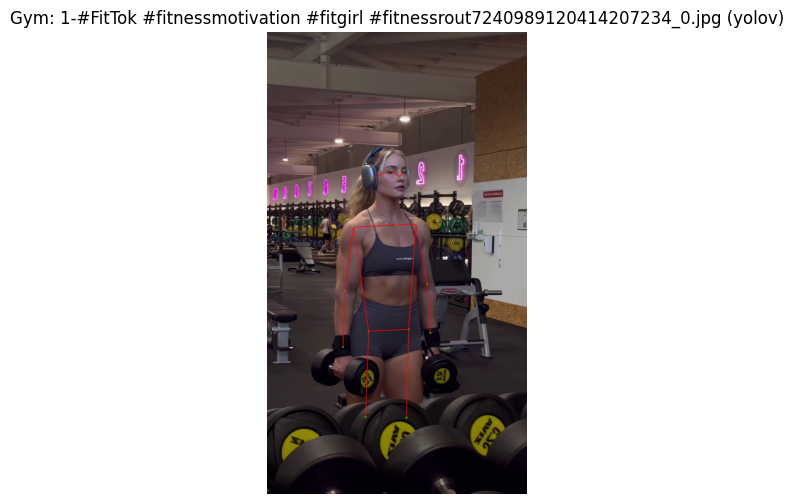

Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_1.jpg: shape=(1920, 1080, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Gym/1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_1.jpg: 640x384 1 person, 13.9ms
Speed: 4.0ms preprocess, 13.9ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 384)


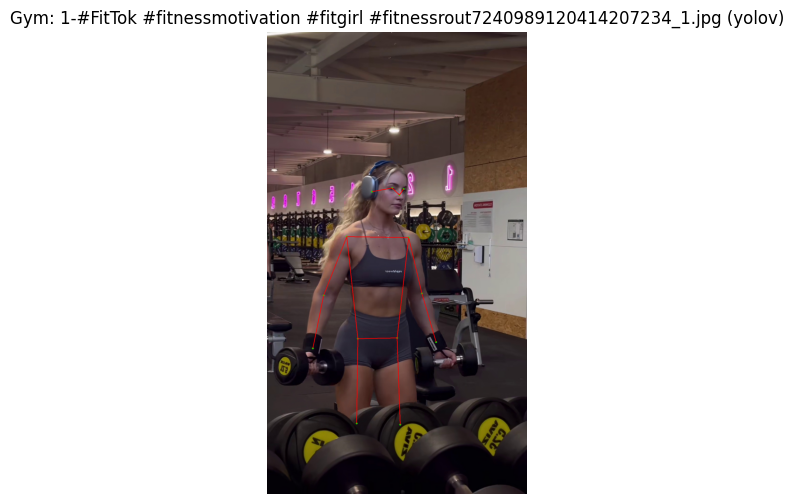

Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_2.jpg: shape=(1920, 1080, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Gym/1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_2.jpg: 640x384 2 persons, 34.5ms
Speed: 3.7ms preprocess, 34.5ms inference, 16.0ms postprocess per image at shape (1, 3, 640, 384)
Skipping 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_2.jpg: No valid keypoints or multiple detections
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_3.jpg: shape=(1920, 1080, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Gym/1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_3.jpg: 640x384 2 persons, 20.6ms
Speed: 17.1ms preprocess, 20.6ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 384)
Skipping 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_3.jpg: No valid keypoints or multiple detecti

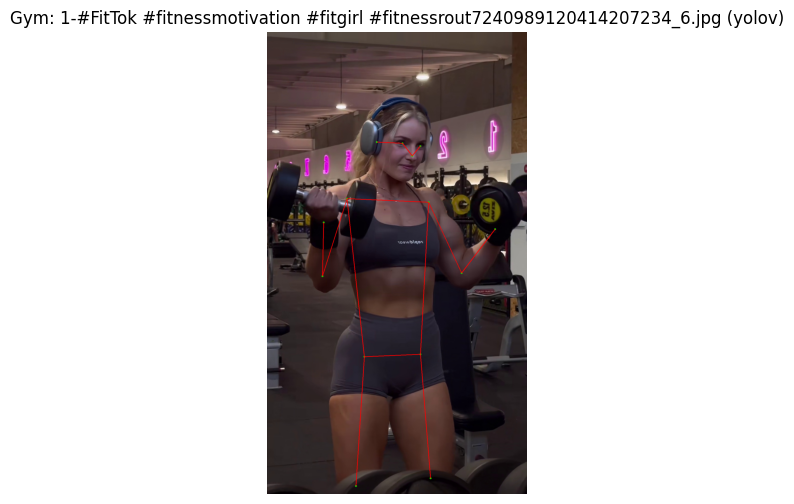

Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_7.jpg: shape=(1920, 1080, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Gym/1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_7.jpg: 640x384 1 person, 22.9ms
Speed: 11.2ms preprocess, 22.9ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 384)
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_8.jpg: shape=(1920, 1080, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Gym/1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_8.jpg: 640x384 2 persons, 11.7ms
Speed: 3.3ms preprocess, 11.7ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 384)
Skipping 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_8.jpg: No valid keypoints or multiple detections
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_9.jpg: shape=(1920, 1080, 3), dtype=uint8

im

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129388 (\N{LEAFY GREEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


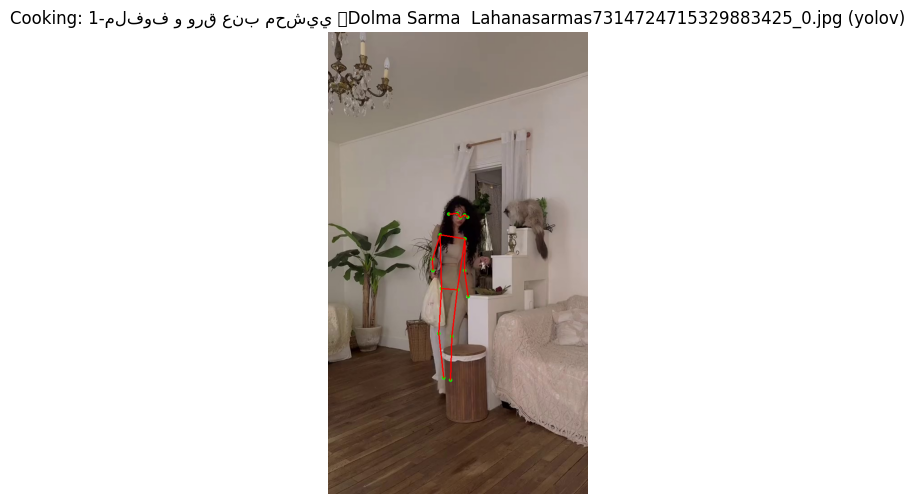

Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_1.jpg: shape=(1024, 576, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Cooking/1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_1.jpg: 640x384 1 person, 38.6ms
Speed: 3.3ms preprocess, 38.6ms inference, 13.9ms postprocess per image at shape (1, 3, 640, 384)


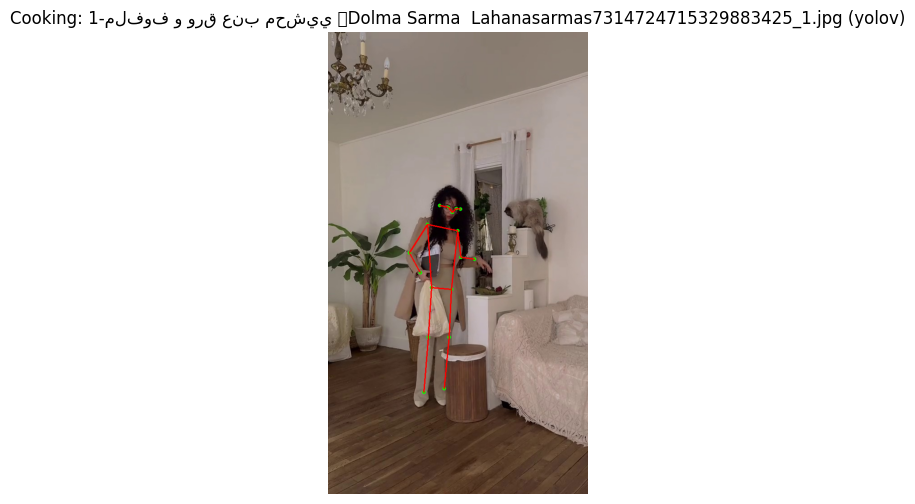

Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_2.jpg: shape=(1024, 576, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Cooking/1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_2.jpg: 640x384 1 person, 13.7ms
Speed: 11.5ms preprocess, 13.7ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 384)


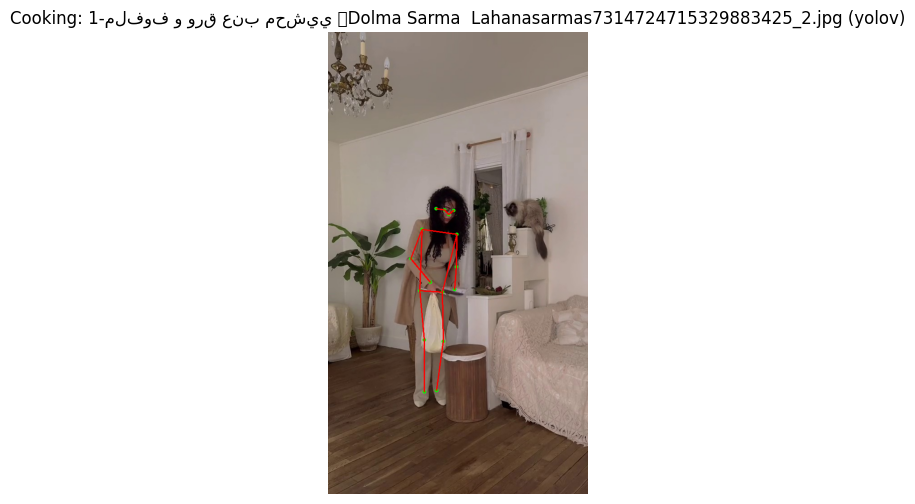

Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_3.jpg: shape=(1024, 576, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Cooking/1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_3.jpg: 640x384 1 person, 14.5ms
Speed: 3.2ms preprocess, 14.5ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 384)
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_4.jpg: shape=(1024, 576, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Cooking/1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_4.jpg: 640x384 1 person, 14.4ms
Speed: 3.1ms preprocess, 14.4ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 384)
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_5.jpg: shape=(1024, 576, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Cooking/1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_5.jp

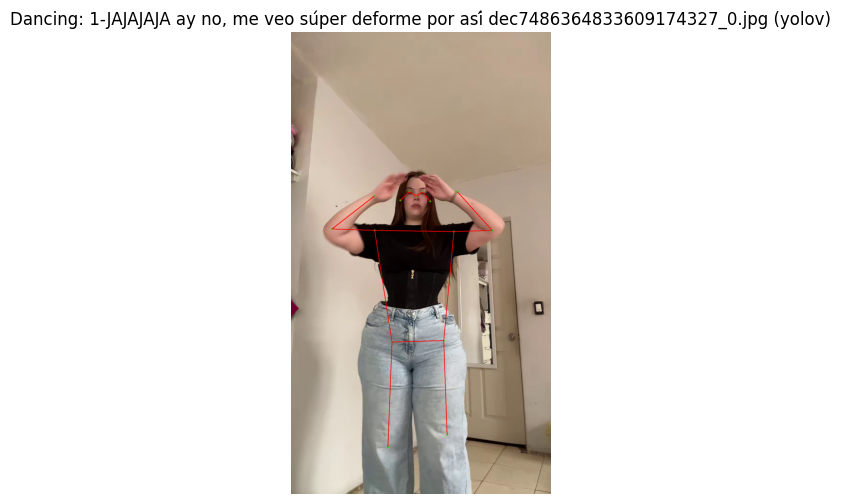

Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_1.jpg: shape=(1920, 1080, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Dancing/1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_1.jpg: 640x384 1 person, 10.8ms
Speed: 3.9ms preprocess, 10.8ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 384)


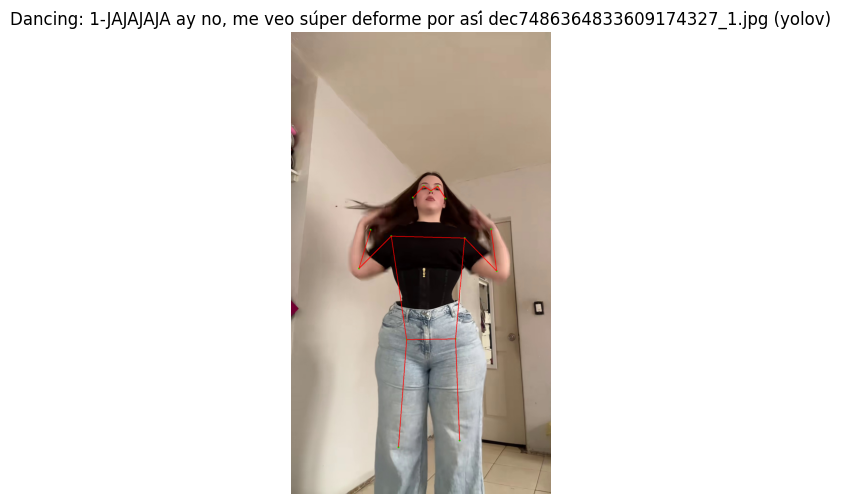

Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_2.jpg: shape=(1920, 1080, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Dancing/1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_2.jpg: 640x384 1 person, 10.8ms
Speed: 3.7ms preprocess, 10.8ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 384)


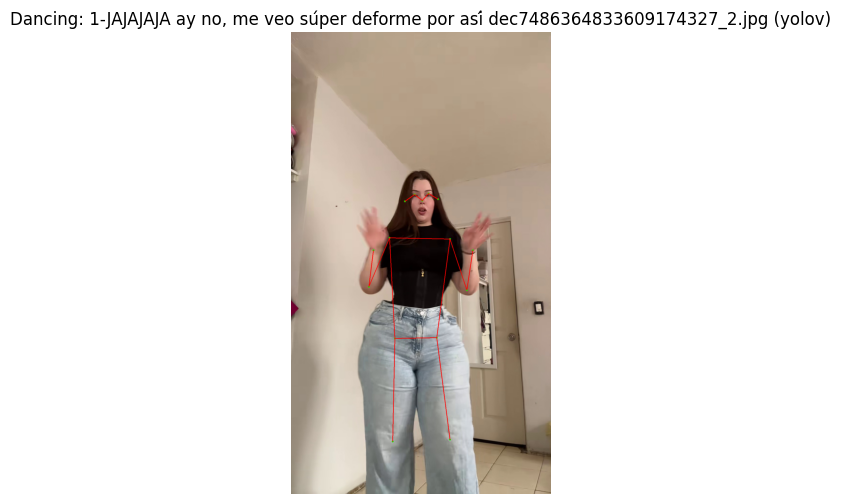

Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_3.jpg: shape=(1920, 1080, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Dancing/1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_3.jpg: 640x384 1 person, 11.5ms
Speed: 4.0ms preprocess, 11.5ms inference, 8.4ms postprocess per image at shape (1, 3, 640, 384)
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_4.jpg: shape=(1920, 1080, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Dancing/1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_4.jpg: 640x384 1 person, 12.2ms
Speed: 4.0ms preprocess, 12.2ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 384)
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_5.jpg: shape=(1920, 1080, 3), dtype=uint8

image 1/1 /content/drive/MyDrive/Data/Frames/Dancing/1-JAJAJAJA ay no, me veo súper deforme por así dec748636483

In [ ]:
# Process yolov model
print("\n=== Processing yolov ===")  # Log the start of YOLOv pose extraction
poses_dir_yolov = os.path.join(POSE_DIR, 'yolov')  # Define directory to store YOLOv pose keypoints

# Extract and save keypoints from frames using YOLOv pose estimation model
all_keypoints_yolov = extract_and_save_poses(
    frames_dir=FRAME_DIR,                    # Directory containing extracted frames for all classes
    poses_dir=POSE_DIR,                      # Base directory to store all pose keypoints
    pose_model='yolov',                      # Specify to use YOLOv pose estimation
    model_path=POSE_MODELS['yolov']['path'], # Path to the YOLOv model weights file
    max_visualizations_per_class=3,          # Visualize up to 3 sample poses per class for inspection
    visualize=True                           # Enable visualization of detected keypoints and skeletons
)

# Log the number of valid poses stored for each class after extraction
for label, keypoints in all_keypoints_yolov.items():
    print(f"Class {label}: {len(keypoints)} poses stored")


## Yolov Model Training

In [ ]:
# Define the subdirectory for saving YOLOv model artifacts (models, encoders, scalers)
model_subdir_yolov = os.path.join(MODEL_DIR, 'yolov')
os.makedirs(model_subdir_yolov, exist_ok=True)  # Create the directory if it doesn't exist

# Define file paths for saving the trained Random Forest model, label encoder, and scaler for YOLOv
model_save_path_yolov = os.path.join(model_subdir_yolov, 'random_forest_yolov.joblib')  # Path to save Random Forest model
le_save_path_yolov = os.path.join(model_subdir_yolov, 'label_encoder_yolov.joblib')      # Path to save label encoder
scaler_save_path_yolov = os.path.join(model_subdir_yolov, 'scaler_yolov.joblib')         # Path to save scaler

# Train and evaluate ML models using the YOLOv pose keypoints
# - poses_dir: directory containing YOLOv pose keypoints for all classes
# - model_save_path: where to save the trained Random Forest model
# - le_save_path: where to save the label encoder
# - scaler_save_path: where to save the feature scaler
# Returns:
#   results_yolov: dictionary with evaluation metrics for each ML model
#   results_df_yolov: DataFrame with metrics for all models (for plotting/comparison)
results_yolov, results_df_yolov = train_and_evaluate_models(
    poses_dir=poses_dir_yolov,
    model_save_path=model_save_path_yolov,
    le_save_path=le_save_path_yolov,
    scaler_save_path=scaler_save_path_yolov
)

# Store the YOLOv results DataFrame in the all_results dictionary for later combined analysis/plotting
all_results['yolov'] = results_df_yolov


Training Logistic Regression...
Evaluation metrics for Logistic Regression:
Accuracy: 0.6571
Precision: 0.6294
Recall: 0.6571
F1-Score: 0.6279
Confusion Matrix:
[[17  1  3]
 [ 0  3  0]
 [ 8  0  3]]
Training SVM...
Evaluation metrics for SVM:
Accuracy: 0.8000
Precision: 0.8052
Recall: 0.8000
F1-Score: 0.8019
Confusion Matrix:
[[17  0  4]
 [ 0  3  0]
 [ 3  0  8]]
Training Random Forest...
Evaluation metrics for Random Forest:
Accuracy: 0.9429
Precision: 0.9516
Recall: 0.9429
F1-Score: 0.9420
Confusion Matrix:
[[20  0  1]
 [ 0  2  1]
 [ 0  0 11]]
Training XGBoost...
Evaluation metrics for XGBoost:
Accuracy: 0.8857
Precision: 0.8898
Recall: 0.8857
F1-Score: 0.8809
Confusion Matrix:
[[19  1  1]
 [ 0  1  2]
 [ 0  0 11]]


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:39:53] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


## Yolov Trained Model Inference

In [ ]:
# Define the path to the input video for inference.

# Define the output path where the annotated video (with predictions and skeletons) will be saved.
output_path_yolov = os.path.join(PREDICTION_DIR, 'yolov', 'output_video.mp4')

# Run inference on the input video using the trained YOLOv pose estimation and classification pipeline.
# - video_path: path to the input video file to process
# - output_path: path to save the output video with visualized predictions
# - pose_model: specify 'yolov' to use YOLOv pose estimation
# - model_path: path to the YOLOv pose model weights
# - clf_model_path: path to the trained Random Forest classifier for YOLOv keypoints
# - le_path: path to the label encoder used during training
# - scaler_path: path to the feature scaler used during training
# Returns:
#   final_pred_yolov: the most frequent predicted class label for the video
#   class_counts_yolov: a dictionary with counts of each predicted class across frames
final_pred_yolov, class_counts_yolov = predict_and_visualize_video(
    video_path=video_path,
    output_path=output_path_yolov,
    pose_model='yolov',
    model_path=POSE_MODELS['yolov']['path'],
    clf_model_path=model_save_path_yolov,
    le_path=le_save_path_yolov,
    scaler_path=scaler_save_path_yolov
)



0: 384x640 (no detections), 14.7ms
Speed: 2.5ms preprocess, 14.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 10.2ms
Speed: 2.4ms preprocess, 10.2ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 22.6ms
Speed: 2.3ms preprocess, 22.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 9.9ms
Speed: 2.2ms preprocess, 9.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 17.3ms
Speed: 3.1ms preprocess, 17.3ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 16.4ms
Speed: 2.8ms preprocess, 16.4ms inference, 5.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 11.6ms
Speed: 2.5ms preprocess, 11.6ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 9.2ms
Speed: 2.4ms preprocess, 9.2ms inference, 0.8ms po

## Mediapipe Pose Estimation


=== Processing mediapipe ===
Processing class: Gym with mediapipe
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_0.jpg: shape=(1920, 1080, 3), dtype=uint8


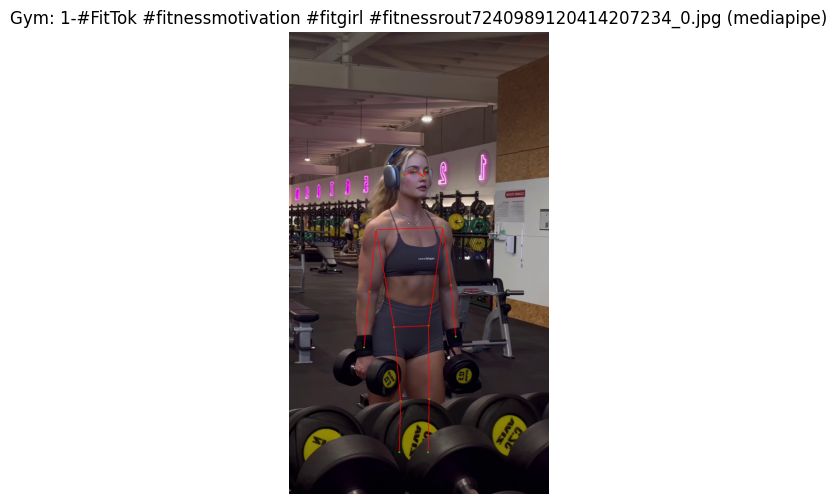

Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_1.jpg: shape=(1920, 1080, 3), dtype=uint8


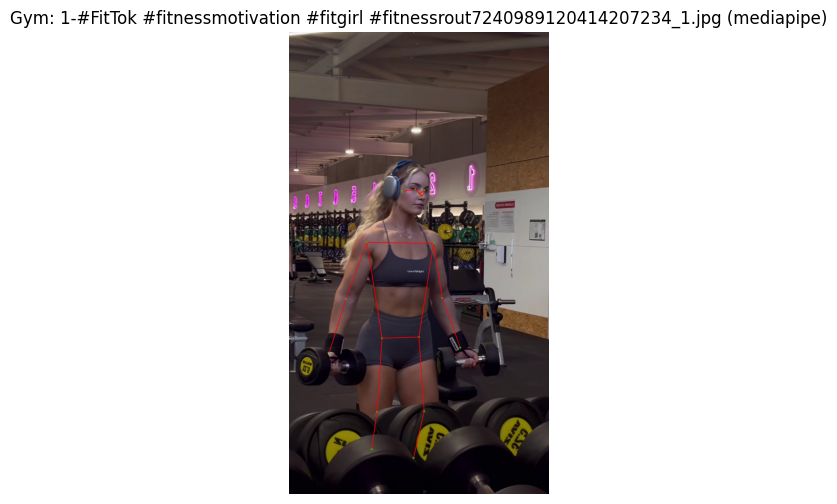

Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_2.jpg: shape=(1920, 1080, 3), dtype=uint8


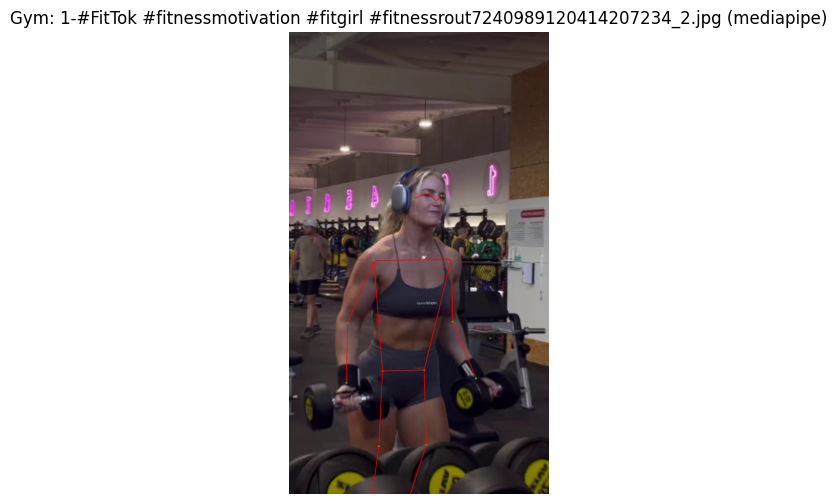

Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_3.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_4.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_5.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_6.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_7.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_8.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_9.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_10.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#F

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129388 (\N{LEAFY GREEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


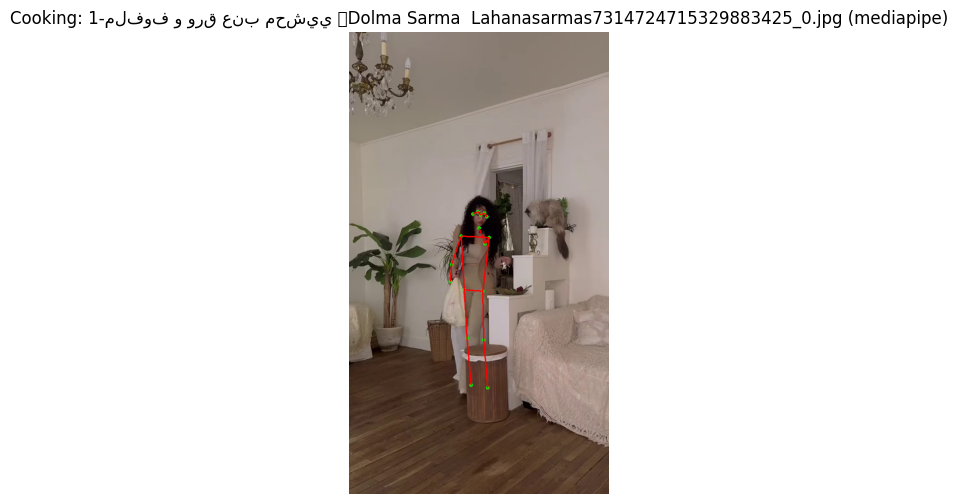

Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_1.jpg: shape=(1024, 576, 3), dtype=uint8


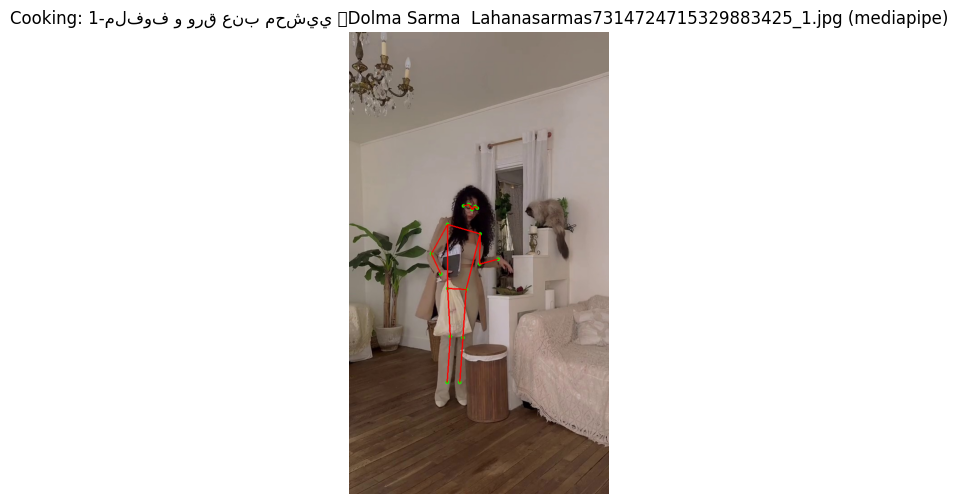

Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_2.jpg: shape=(1024, 576, 3), dtype=uint8


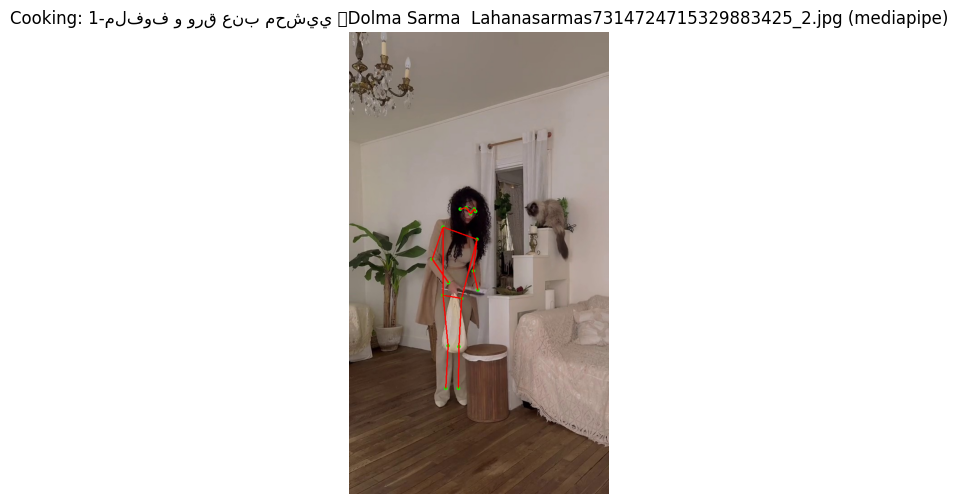

Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_3.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_4.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_5.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_6.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_7.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_8.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_9.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_10.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ور

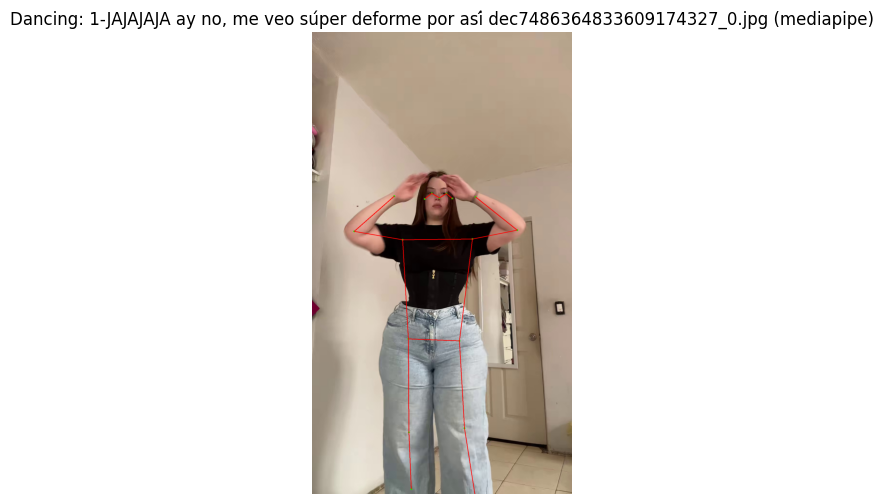

Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_1.jpg: shape=(1920, 1080, 3), dtype=uint8


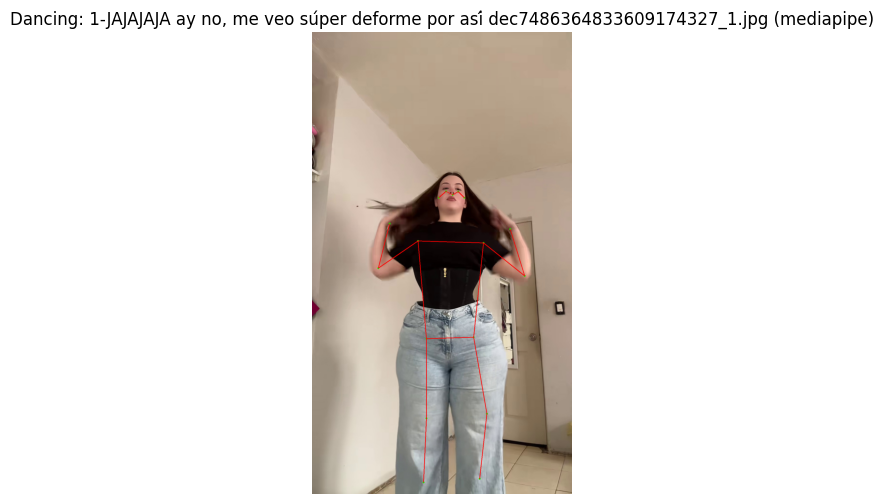

Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_2.jpg: shape=(1920, 1080, 3), dtype=uint8


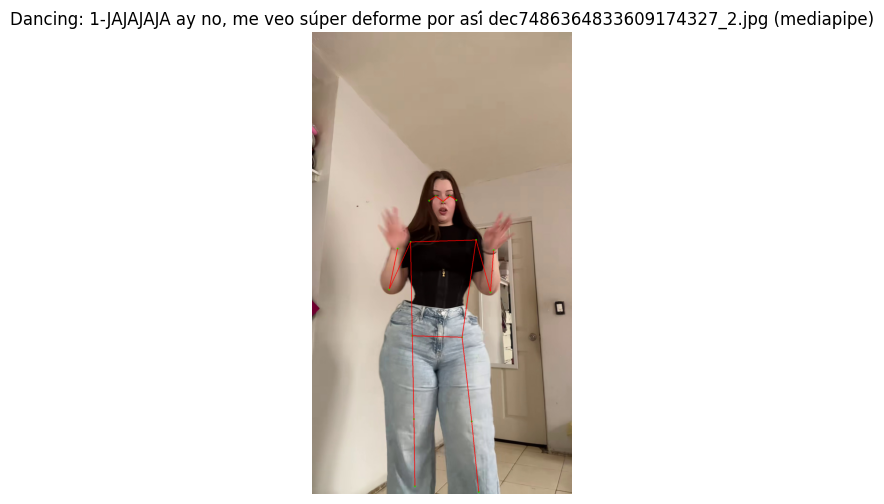

Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_3.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_4.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_5.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_6.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_7.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_8.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_9.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_10.jpg: shape=(1920, 1080, 3), dtype=uint8

In [ ]:
# Process mediapipe model
print("\n=== Processing mediapipe ===")  # Log the start of MediaPipe pose extraction

# Define the directory to store MediaPipe pose keypoints
poses_dir_mediapipe = os.path.join(POSE_DIR, 'mediapipe')

# Extract and save keypoints from frames using the MediaPipe pose estimation model
# - frames_dir: directory containing extracted frames for all classes
# - poses_dir: base directory to store all pose keypoints
# - pose_model: specify 'mediapipe' to use MediaPipe pose estimation
# - model_path: path to the model weights (not required for MediaPipe, but kept for consistency)
# - max_visualizations_per_class: visualize up to 3 sample poses per class for inspection
# - visualize: enable visualization of detected keypoints and skeletons
all_keypoints_mediapipe = extract_and_save_poses(
    frames_dir=FRAME_DIR,
    poses_dir=POSE_DIR,
    pose_model='mediapipe',
    model_path=POSE_MODELS['mediapipe'].get('path'),
    max_visualizations_per_class=3,
    visualize=True
)

# Log the number of valid poses stored for each class after extraction
for label, keypoints in all_keypoints_mediapipe.items():
    print(f"Class {label}: {len(keypoints)} poses stored")


## Mediapipe Model Training

In [ ]:
# Define the subdirectory for saving MediaPipe model artifacts (models, encoders, scalers)
model_subdir_mediapipe = os.path.join(MODEL_DIR, 'mediapipe')
os.makedirs(model_subdir_mediapipe, exist_ok=True)  # Create the directory if it doesn't exist

# Define file paths for saving the trained Random Forest model, label encoder, and scaler for MediaPipe
model_save_path_mediapipe = os.path.join(model_subdir_mediapipe, 'random_forest_mediapipe.joblib')  # Path to save Random Forest model
le_save_path_mediapipe = os.path.join(model_subdir_mediapipe, 'label_encoder_mediapipe.joblib')      # Path to save label encoder
scaler_save_path_mediapipe = os.path.join(model_subdir_mediapipe, 'scaler_mediapipe.joblib')         # Path to save scaler

# Train and evaluate ML models using the MediaPipe pose keypoints
# - poses_dir: directory containing MediaPipe pose keypoints for all classes
# - model_save_path: where to save the trained Random Forest model
# - le_save_path: where to save the label encoder
# - scaler_save_path: where to save the feature scaler
# Returns:
#   results_mediapipe: dictionary with evaluation metrics for each ML model
#   results_df_mediapipe: DataFrame with metrics for all models (for plotting/comparison)
results_mediapipe, results_df_mediapipe = train_and_evaluate_models(
    poses_dir=poses_dir_mediapipe,
    model_save_path=model_save_path_mediapipe,
    le_save_path=le_save_path_mediapipe,
    scaler_save_path=scaler_save_path_mediapipe
)

# Store the MediaPipe results DataFrame in the all_results dictionary for later combined analysis/plotting
all_results['mediapipe'] = results_df_mediapipe


Training Logistic Regression...
Evaluation metrics for Logistic Regression:
Accuracy: 0.6182
Precision: 0.6194
Recall: 0.6182
F1-Score: 0.6170
Confusion Matrix:
[[15  3  6]
 [ 4 14  0]
 [ 8  0  5]]
Training SVM...
Evaluation metrics for SVM:
Accuracy: 0.8182
Precision: 0.8237
Recall: 0.8182
F1-Score: 0.8194
Confusion Matrix:
[[18  1  5]
 [ 1 17  0]
 [ 3  0 10]]
Training Random Forest...
Evaluation metrics for Random Forest:
Accuracy: 0.9455
Precision: 0.9469
Recall: 0.9455
F1-Score: 0.9456
Confusion Matrix:
[[23  1  0]
 [ 1 17  0]
 [ 1  0 12]]
Training XGBoost...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:40:53] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Evaluation metrics for XGBoost:
Accuracy: 0.9091
Precision: 0.9133
Recall: 0.9091
F1-Score: 0.9081
Confusion Matrix:
[[20  2  2]
 [ 1 17  0]
 [ 0  0 13]]


## Mediapipe Trained Model Inference

In [ ]:
# Define the output path where the annotated video (with predictions and skeletons) for MediaPipe will be saved.
output_path_mediapipe = os.path.join(PREDICTION_DIR, 'mediapipe', 'output_video.mp4')

# Run inference on the input video using the trained MediaPipe pose estimation and classification pipeline.
# - video_path: path to the input video file to process (already defined above)
# - output_path: path to save the output video with visualized predictions for MediaPipe
# - pose_model: specify 'mediapipe' to use MediaPipe pose estimation
# - model_path: path to the model weights (not required for MediaPipe, but kept for consistency)
# - clf_model_path: path to the trained Random Forest classifier for MediaPipe keypoints
# - le_path: path to the label encoder used during training
# - scaler_path: path to the feature scaler used during training
# Returns:
#   final_pred_mediapipe: the most frequent predicted class label for the video
#   class_counts_mediapipe: a dictionary with counts of each predicted class across frames
final_pred_mediapipe, class_counts_mediapipe = predict_and_visualize_video(
    video_path=video_path,
    output_path=output_path_mediapipe,
    pose_model='mediapipe',
    model_path=POSE_MODELS['mediapipe'].get('path'),
    clf_model_path=model_save_path_mediapipe,
    le_path=le_save_path_mediapipe,
    scaler_path=scaler_save_path_mediapipe
)


Video Prediction Summary (mediapipe):
Total frames with valid poses: 407
Final Prediction: Dancing
Class Counts:
  Dancing: 322 frames (79.12%)
  Cooking: 85 frames (20.88%)
Output video saved to: /content/drive/MyDrive/Data/Predictions/mediapipe/output_video.mp4


## Blazepose Pose Estimation


=== Processing blazepose ===
Processing class: Gym with blazepose
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_0.jpg: shape=(1920, 1080, 3), dtype=uint8


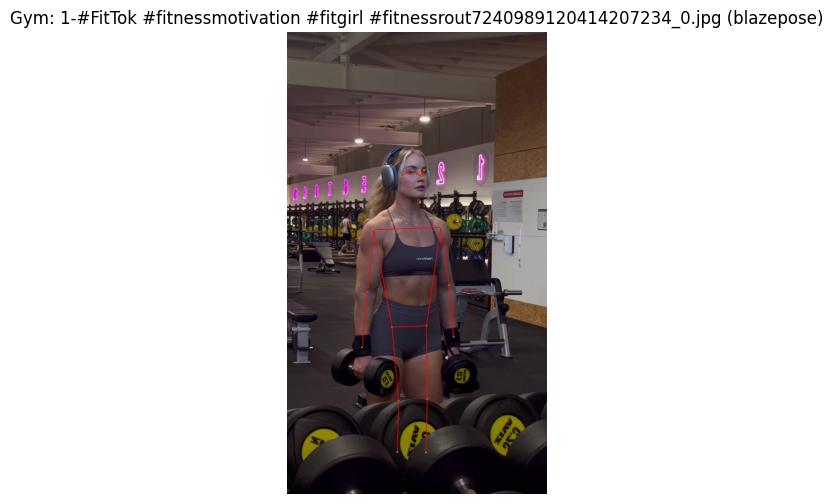

Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_1.jpg: shape=(1920, 1080, 3), dtype=uint8


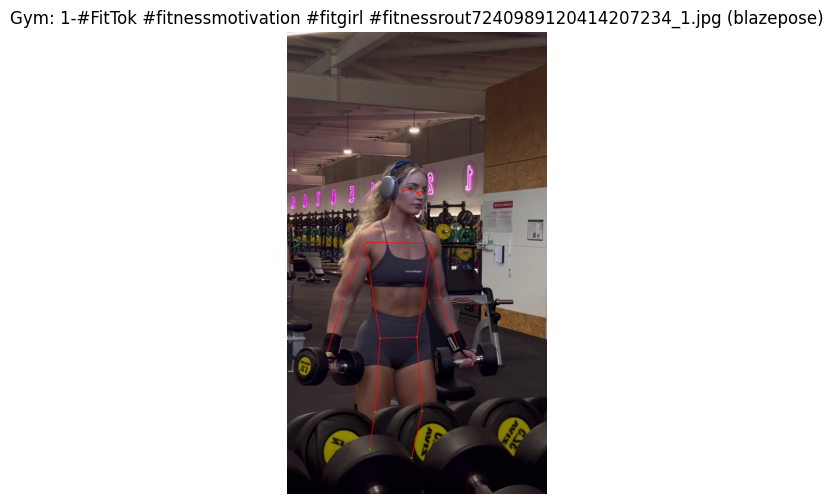

Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_2.jpg: shape=(1920, 1080, 3), dtype=uint8


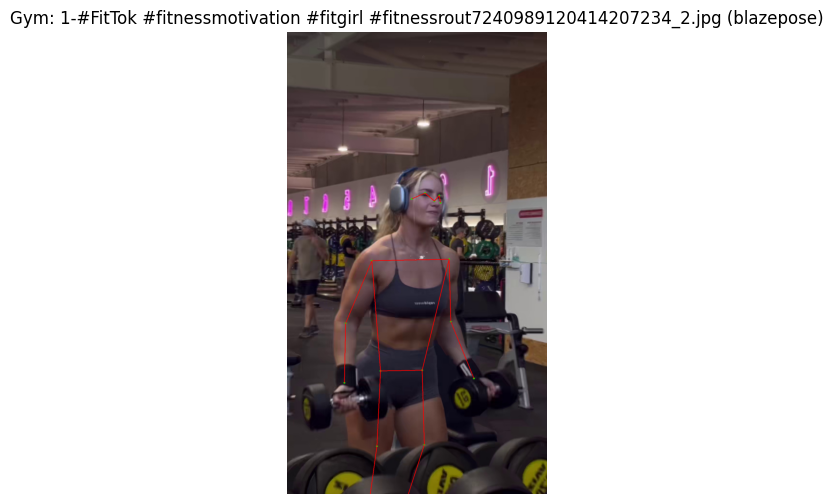

Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_3.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_4.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_5.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_6.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_7.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_8.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_9.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#FitTok #fitnessmotivation #fitgirl #fitnessrout7240989120414207234_10.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-#F

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129388 (\N{LEAFY GREEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


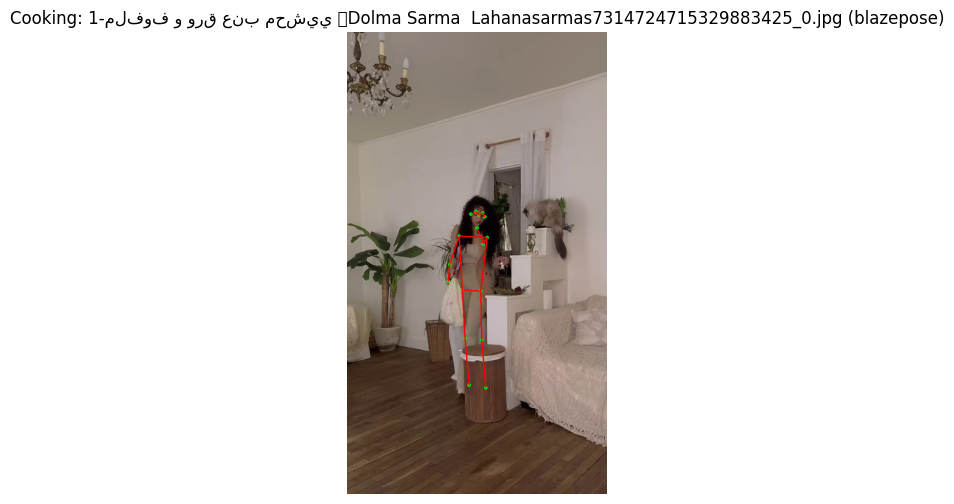

Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_1.jpg: shape=(1024, 576, 3), dtype=uint8


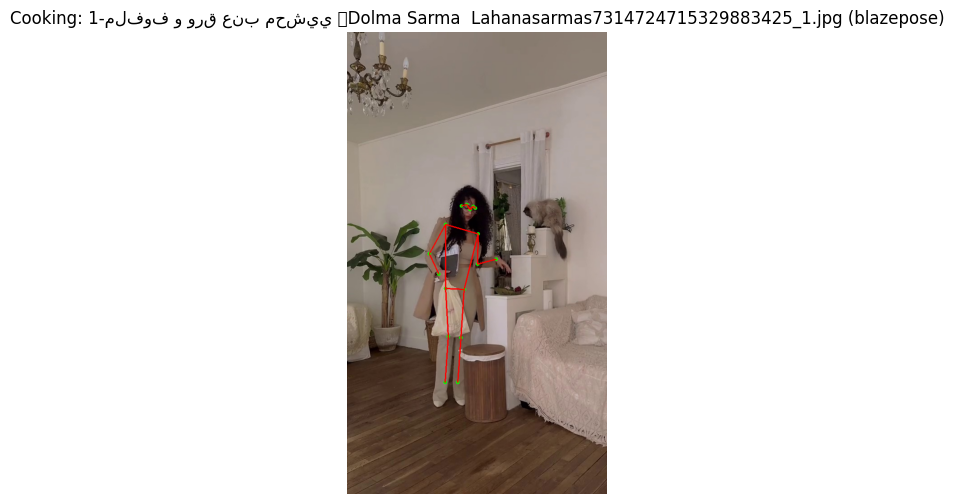

Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_2.jpg: shape=(1024, 576, 3), dtype=uint8


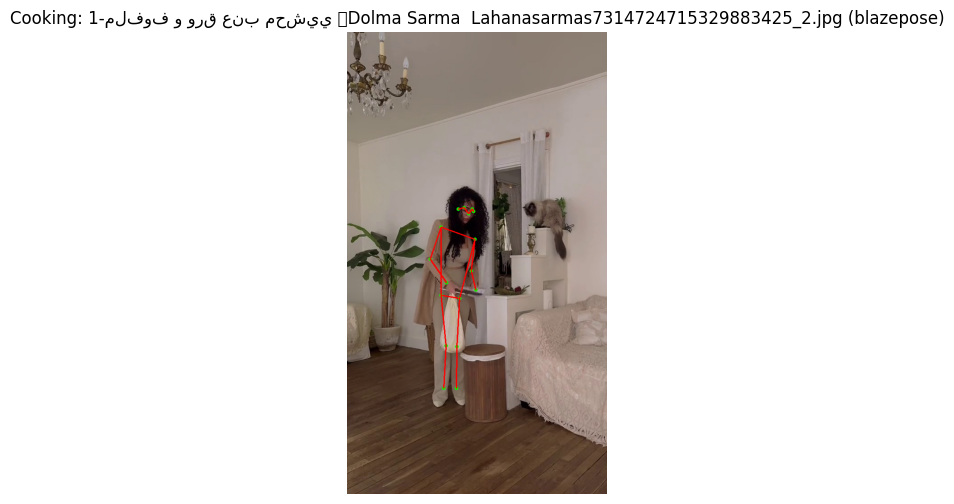

Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_3.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_4.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_5.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_6.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_7.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_8.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_9.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ورق عنب محشيي 🥬Dolma Sarma  Lahanasarmas7314724715329883425_10.jpg: shape=(1024, 576, 3), dtype=uint8
Processing 1-ملفوف و ور

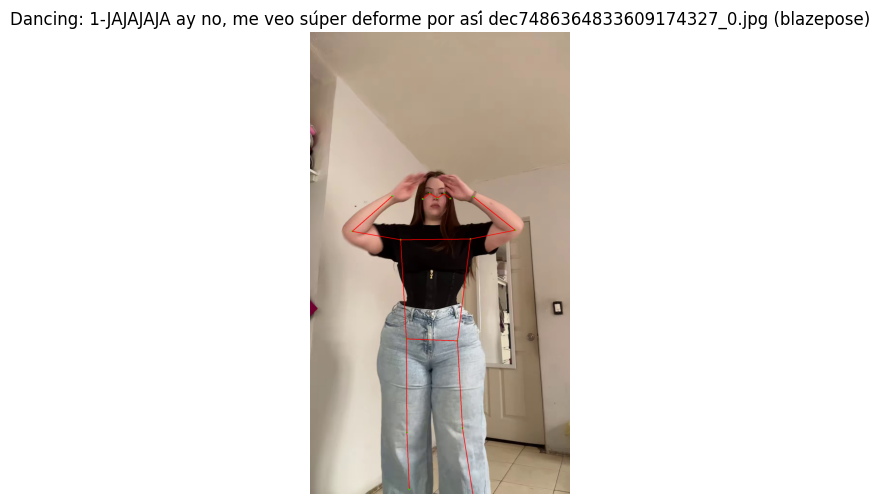

Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_1.jpg: shape=(1920, 1080, 3), dtype=uint8


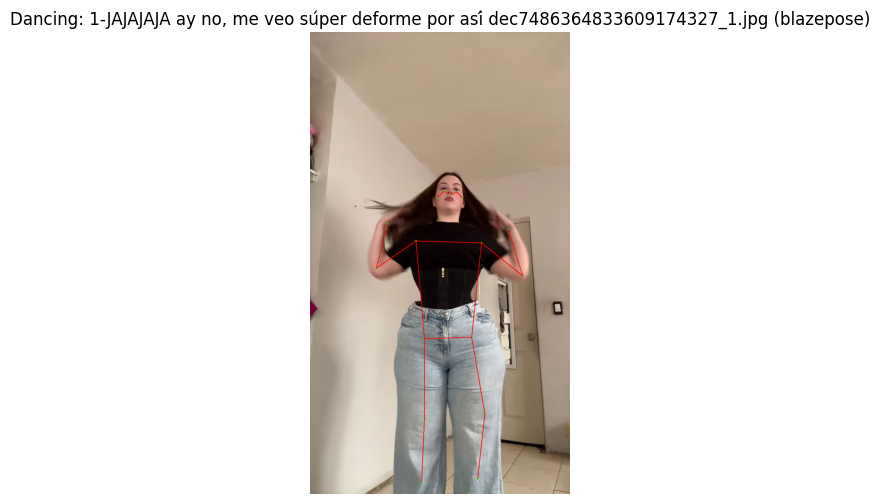

Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_2.jpg: shape=(1920, 1080, 3), dtype=uint8


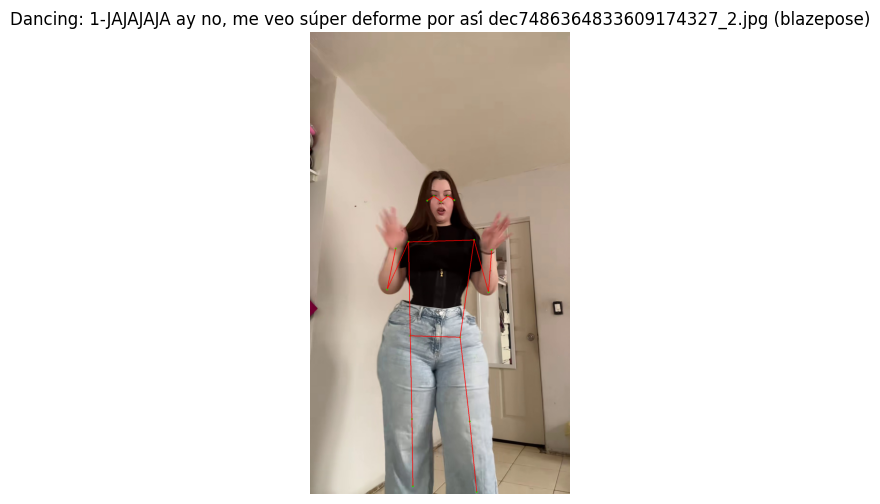

Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_3.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_4.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_5.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_6.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_7.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_8.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_9.jpg: shape=(1920, 1080, 3), dtype=uint8
Processing 1-JAJAJAJA ay no, me veo súper deforme por así dec7486364833609174327_10.jpg: shape=(1920, 1080, 3), dtype=uint8

In [ ]:
# Process blazepose model
print("\n=== Processing blazepose ===")  # Log the start of BlazePose pose extraction

# Define the directory to store BlazePose pose keypoints
poses_dir_blazepose = os.path.join(POSE_DIR, 'blazepose')

# Extract and save keypoints from frames using the BlazePose pose estimation model
# - frames_dir: directory containing extracted frames for all classes
# - poses_dir: base directory to store all pose keypoints
# - pose_model: specify 'blazepose' to use BlazePose pose estimation
# - model_path: path to the model weights (not required for BlazePose, but kept for consistency)
# - max_visualizations_per_class: visualize up to 3 sample poses per class for inspection
# - visualize: enable visualization of detected keypoints and skeletons
all_keypoints_blazepose = extract_and_save_poses(
    frames_dir=FRAME_DIR,
    poses_dir=POSE_DIR,
    pose_model='blazepose',
    model_path=POSE_MODELS['blazepose'].get('path'),
    max_visualizations_per_class=3,
    visualize=True
)

# Log the number of valid poses stored for each class after extraction
for label, keypoints in all_keypoints_blazepose.items():
    print(f"Class {label}: {len(keypoints)} poses stored")


## Blazepose Model Training

In [ ]:
# Define the subdirectory for saving BlazePose model artifacts (models, encoders, scalers)
model_subdir_blazepose = os.path.join(MODEL_DIR, 'blazepose')
os.makedirs(model_subdir_blazepose, exist_ok=True)  # Create the directory if it doesn't exist

# Define file paths for saving the trained Random Forest model, label encoder, and scaler for BlazePose
model_save_path_blazepose = os.path.join(model_subdir_blazepose, 'random_forest_blazepose.joblib')  # Path to save Random Forest model
le_save_path_blazepose = os.path.join(model_subdir_blazepose, 'label_encoder_blazepose.joblib')      # Path to save label encoder
scaler_save_path_blazepose = os.path.join(model_subdir_blazepose, 'scaler_blazepose.joblib')         # Path to save scaler

# Train and evaluate ML models using the BlazePose pose keypoints
# - poses_dir: directory containing BlazePose pose keypoints for all classes
# - model_save_path: where to save the trained Random Forest model
# - le_save_path: where to save the label encoder
# - scaler_save_path: where to save the feature scaler
# Returns:
#   results_blazepose: dictionary with evaluation metrics for each ML model
#   results_df_blazepose: DataFrame with metrics for all models (for plotting/comparison)
results_blazepose, results_df_blazepose = train_and_evaluate_models(
    poses_dir=poses_dir_blazepose,
    model_save_path=model_save_path_blazepose,
    le_save_path=le_save_path_blazepose,
    scaler_save_path=scaler_save_path_blazepose
)

# Store the BlazePose results DataFrame in the all_results dictionary for later combined analysis/plotting
all_results['blazepose'] = results_df_blazepose


Training Logistic Regression...
Evaluation metrics for Logistic Regression:
Accuracy: 0.6182
Precision: 0.6194
Recall: 0.6182
F1-Score: 0.6170
Confusion Matrix:
[[15  3  6]
 [ 4 14  0]
 [ 8  0  5]]
Training SVM...
Evaluation metrics for SVM:
Accuracy: 0.8182
Precision: 0.8237
Recall: 0.8182
F1-Score: 0.8194
Confusion Matrix:
[[18  1  5]
 [ 1 17  0]
 [ 3  0 10]]
Training Random Forest...
Evaluation metrics for Random Forest:
Accuracy: 0.9455
Precision: 0.9469
Recall: 0.9455
F1-Score: 0.9456
Confusion Matrix:
[[23  1  0]
 [ 1 17  0]
 [ 1  0 12]]
Training XGBoost...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:42:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Evaluation metrics for XGBoost:
Accuracy: 0.9091
Precision: 0.9133
Recall: 0.9091
F1-Score: 0.9081
Confusion Matrix:
[[20  2  2]
 [ 1 17  0]
 [ 0  0 13]]


## Blazepose Trained Model Inference

In [ ]:
# Define the output path where the annotated video (with predictions and skeletons) for BlazePose will be saved.
output_path_blazepose = os.path.join(PREDICTION_DIR, 'blazepose', 'output_video.mp4')

# Run inference on the input video using the trained BlazePose pose estimation and classification pipeline.
# - video_path: path to the input video file to process (already defined above)
# - output_path: path to save the output video with visualized predictions for BlazePose
# - pose_model: specify 'blazepose' to use BlazePose pose estimation
# - model_path: path to the model weights (not required for BlazePose, but kept for consistency)
# - clf_model_path: path to the trained Random Forest classifier for BlazePose keypoints
# - le_path: path to the label encoder used during training
# - scaler_path: path to the feature scaler used during training
# Returns:
#   final_pred_blazepose: the most frequent predicted class label for the video
#   class_counts_blazepose: a dictionary with counts of each predicted class across frames
final_pred_blazepose, class_counts_blazepose = predict_and_visualize_video(
    video_path=video_path,
    output_path=output_path_blazepose,
    pose_model='blazepose',
    model_path=POSE_MODELS['blazepose'].get('path'),
    clf_model_path=model_save_path_blazepose,
    le_path=le_save_path_blazepose,
    scaler_path=scaler_save_path_blazepose
)


Video Prediction Summary (blazepose):
Total frames with valid poses: 407
Final Prediction: Dancing
Class Counts:
  Dancing: 322 frames (79.12%)
  Cooking: 85 frames (20.88%)
Output video saved to: /content/drive/MyDrive/Data/Predictions/blazepose/output_video.mp4


In [ ]:
print(all_results)


{'yolov':                  Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.657143   0.629429  0.657143  0.627872
1                  SVM  0.800000   0.805238  0.800000  0.801909
2        Random Forest  0.942857   0.951648  0.942857  0.942033
3              XGBoost  0.885714   0.889796  0.885714  0.880857, 'mediapipe':                  Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.618182   0.619381  0.618182  0.616988
1                  SVM  0.818182   0.823691  0.818182  0.819424
2        Random Forest  0.945455   0.946909  0.945455  0.945647
3              XGBoost  0.909091   0.913256  0.909091  0.908096, 'blazepose':                  Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.618182   0.619381  0.618182  0.616988
1                  SVM  0.818182   0.823691  0.818182  0.819424
2        Random Forest  0.945455   0.946909  0.945455  0.945647
3              XGBoost  0.909091   0.913256  0.909091  0.908096}


## Function to Plot Comparison of Evaluation Metrics Between Models

Data/Models/Combined

In [ ]:
# Function to plot combined comparison of evaluation metrics across all pose estimation and ML models
def plot_combined_comparison(all_results, output_dir):
    """
    Plot combined comparison of all ML models across all pose estimation models.

    Args:
        all_results (dict): Dictionary where keys are pose model names (e.g., 'yolov', 'mediapipe', 'blazepose')
                            and values are DataFrames containing evaluation metrics for each ML model.
        output_dir (str): Directory where the combined CSV and plot will be saved.
    """
    combined_results = []
    # Iterate through each pose model's results and add a column indicating the pose model
    for pose_model, df in all_results.items():
        df['Pose_Model'] = pose_model  # Add a column to identify the pose model
        combined_results.append(df)    # Collect all DataFrames for concatenation

    # If no results are available, log an error and exit the function
    if not combined_results:
        print("No performance data found for combined comparison")
        return

    # Concatenate all results into a single DataFrame for combined analysis
    combined_df = pd.concat(combined_results, ignore_index=True)
    os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists

    # Save the combined DataFrame as a CSV file for record-keeping and further analysis
    combined_csv_path = os.path.join(output_dir, 'combined_model_performance.csv')
    combined_df.to_csv(combined_csv_path, index=False)
    print(f"Combined performance data saved to: {combined_csv_path}")

    # Define the metrics and model names for plotting
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    ml_models = combined_df['Model'].unique()       # List of ML model names (e.g., 'Random Forest', 'SVM')
    pose_models = combined_df['Pose_Model'].unique()  # List of pose estimation models

    plt.figure(figsize=(16, 10))  # Set the overall figure size for the combined plot
    x = np.arange(len(ml_models)) # X-axis positions for ML models
    width = 0.25                  # Width of each bar in the bar plot
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Color palette for different pose models

    # Loop through each metric and create a subplot for it
    for j, metric in enumerate(metrics):
        plt.subplot(2, 2, j + 1)  # Arrange subplots in a 2x2 grid
        for i, pose_model in enumerate(pose_models):
            # Filter the DataFrame for the current pose model
            df_filtered = combined_df[combined_df['Pose_Model'] == pose_model]
            if df_filtered.empty:
                continue  # Skip if no data for this pose model
            # Ensure the values are in the correct order for each ML model
            values = [df_filtered[df_filtered['Model'] == ml_model][metric].values[0] if ml_model in df_filtered['Model'].values else 0
                      for ml_model in ml_models]
            # Plot the bar for this pose model and metric
            plt.bar(x + i * width, values, width, label=pose_model, color=colors[i % len(colors)]) # Use modulo for color cycling
            # Annotate each bar with its value (if greater than 0)
            for k, value in enumerate(values):
                if value > 0:
                    plt.text(k + i * width, value + 0.01, f"{value:.4f}", ha='center', va='bottom', fontsize=8) # Reduced fontsize

        plt.xlabel('ML Models')  # X-axis label
        plt.ylabel('Score')      # Y-axis label
        plt.title(f'{metric} Comparison Across Pose Models')  # Title for each subplot
        plt.xticks(x + width, ml_models)  # Set x-tick positions and labels
        plt.legend(title='Pose Model')    # Add legend for pose models
        plt.ylim(0, 1.1)                 # Extend y-limit slightly for text annotations

    plt.tight_layout()  # Adjust subplot spacing for clarity
    # Save the combined comparison plot as a PNG file
    combined_plot_path = os.path.join(output_dir, 'combined_model_metrics_comparison.png')
    plt.savefig(combined_plot_path)
    plt.close()
    print(f"Combined comparison plot saved to: {combined_plot_path}")

# Call the combined plotting function after training and evaluation for all models
plot_combined_comparison(all_results, os.path.join(MODEL_DIR, 'combined'))


Combined performance data saved to: /content/drive/MyDrive/Data/Models/combined/combined_model_performance.csv
Combined comparison plot saved to: /content/drive/MyDrive/Data/Models/combined/combined_model_metrics_comparison.png


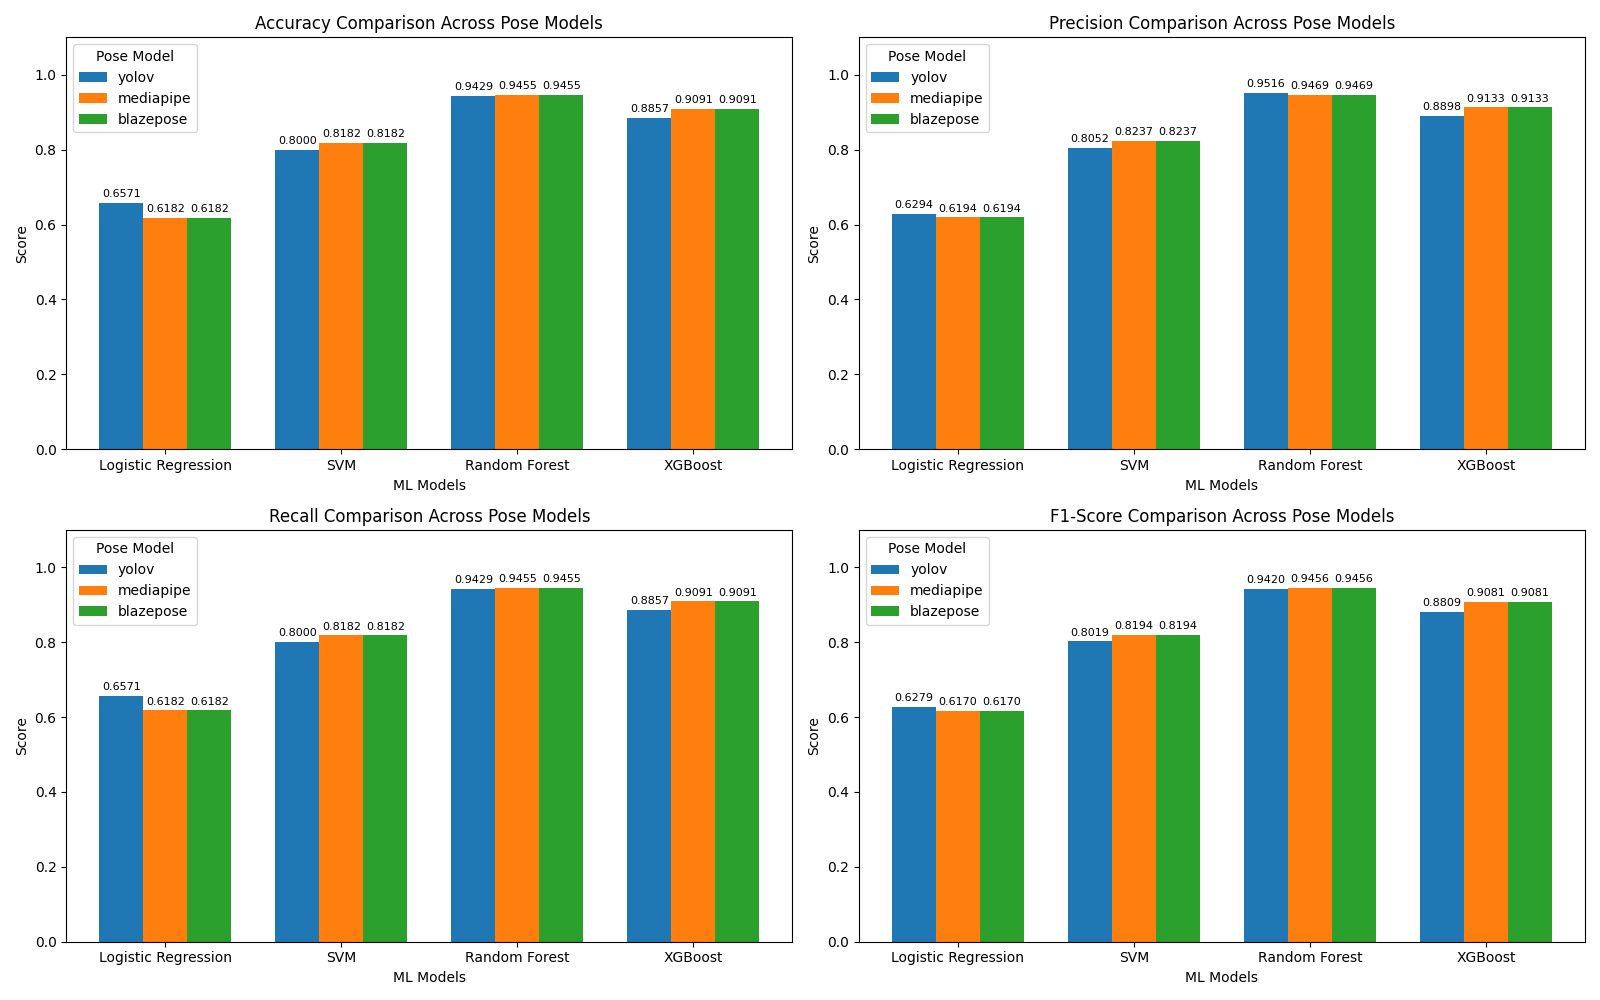

In [ ]:
Image(filename='/content/drive/MyDrive/Data/Models/combined/combined_model_metrics_comparison.png', width=1200)
